At B:
  Ic            = 68.39 A
  Ic_w          = 17.10 A/mm
  Jc_tape_mm2   = 170.99 A/mm²
  Je_40       = 51.30 A/mm²


/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_60094/2637635223.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


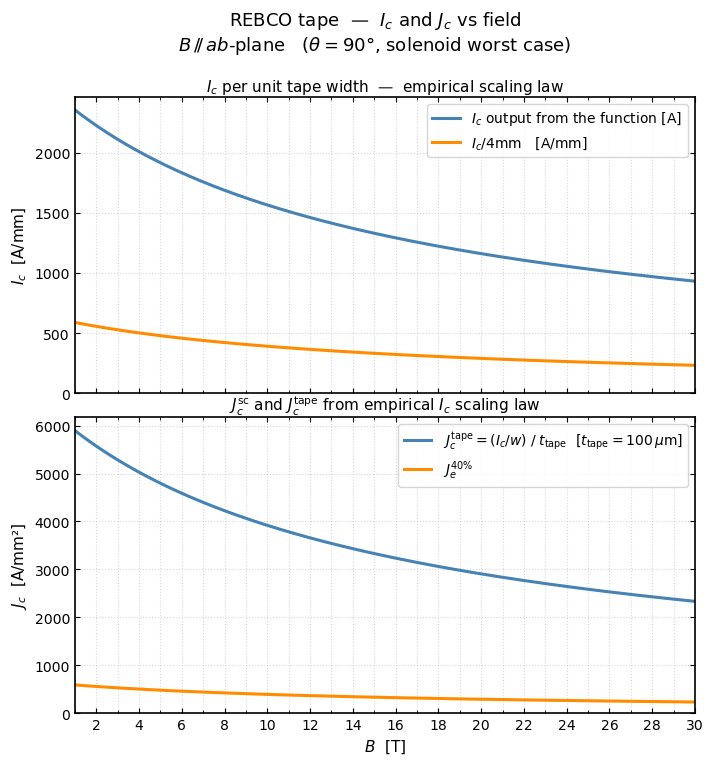

Saved → Ic_Jc_tape_sc_vs_B.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot Ic_tape [A/mm] and Jc_tape / Jc_sc [A/mm²] vs B (1 T to 20 T)
# Uses the standalone Ic_tape function (returns A/m per unit tape width).
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
# Ic_tape scaling law
# ─────────────────────────────────────────────────────────────────────────────

def Ic_tape(b, theta):
    """
    Critical current per unit tape width [A].

    Parameters:
        b     : field magnitude [T]  — float or np.ndarray
        theta : field angle [rad] w.r.t. c-axis
                0    = B // c-axis
                pi/2 = B // ab-plane  (solenoid worst case)

    Returns:
        Ic per unit tape width [A]
    """
    k0     = 8870
    k1     = 18500
    alpha0 = 1.3
    alpha1 = 0.809
    beta0  = 13.8
    beta1  = 13.8
    phi1   = -0.180 * np.pi / 180
    c1     = 2.15

    omega = c1 * (b + (1 / c1)**(5 / 3))**(3 / 5)

    return (
        k0 / (b + beta0)**alpha0
        + k1 / (b + beta1)**alpha1
        * (omega**2 * np.cos(theta - phi1)**2
           + np.sin(theta - phi1)**2)**(-0.5)
    )


# ─────────────────────────────────────────────────────────────────────────────
# Tape geometry
# ─────────────────────────────────────────────────────────────────────────────
t_tape_mm = 0.1     # Total tape thickness [mm]
t_sc_mm   = 0.002   # SC layer thickness   [mm]  (2 µm)
w_tape_mm = 4.0     # Tape width           [mm]

theta_solenoid = np.pi / 2    # B // ab-plane — worst case
# theta_solenoid = 0

# ─────────────────────────────────────────────────────────────────────────────
# Field array
# ─────────────────────────────────────────────────────────────────────────────
b_arr = np.linspace(1.0, 30, 500)   # [T]

# ─────────────────────────────────────────────────────────────────────────────
# Compute curves  — Ic_tape returns [A] per unit tape width
# ─────────────────────────────────────────────────────────────────────────────
ic         = Ic_tape(b_arr, theta_solenoid)   # [A] for 4 mm wide tape
ic_w       = ic / w_tape_mm                   # [A/mm]  per mm of tape width

jc_tape_mm2 = ic_w / t_tape_mm               # [A/mm²]  full tape cross-section
je_40       = jc_tape_mm2 * (1 - 0.90)        # [A/mm²]  engineering Jc with 40% fill factor

# ─────────────────────────────────────────────────────────────────────────────
# Print values at B = 50 T
# ─────────────────────────────────────────────────────────────────────────────
ic_50         = Ic_tape(50, 0)   # [A] for 4 mm wide tape
ic_w_50       = ic_50 / w_tape_mm             # [A/mm]  per mm of tape width
jc_tape_mm2_50 = ic_w_50 / t_tape_mm         # [A/mm²]  full tape cross-section
je_40_50      = jc_tape_mm2_50 * (1 - 0.4)/2   # [A/mm²]  engineering Jc with 40% fill factor, divided by 2 to have results similar to Bernardo

print(f"At B:")
print(f"  Ic            = {ic_50:.2f} A")
print(f"  Ic_w          = {ic_w_50:.2f} A/mm")
print(f"  Jc_tape_mm2   = {jc_tape_mm2_50:.2f} A/mm²")
print(f"  Je_40       = {je_40_50:.2f} A/mm²")

# ─────────────────────────────────────────────────────────────────────────────
# Figure  —  2 panels, shared x-axis
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

fig.suptitle(
    r"REBCO tape  —  $I_c$ and $J_c$ vs field"
    "\n"
    r"$B \,/\!/\, ab$-plane   ($\theta = 90°$, solenoid worst case)",
    fontsize=13, y=0.99,
)

# ── Panel 1 : Ic per unit width [A/mm] ───────────────────────────────────────
ax1.plot(b_arr, ic,   color="steelblue",  lw=2.2,
         label=r"$I_c$ output from the function [A]")
ax1.plot(b_arr, ic_w, color="darkorange", lw=2.2,
         label=r"$I_c$/4mm   [A/mm]")

ax1.set_ylabel(r"$I_c$  [A/mm]", fontsize=11)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=10, loc="upper right")
ax1.grid(True, which="both", ls=":", alpha=0.5)
ax1.set_title(
    r"$I_c$ per unit tape width  —  empirical scaling law",
    fontsize=11, pad=4,
)

# ── Panel 2 : Jc_tape and Je_40 [A/mm²] ─────────────────────────────────────
ax2.plot(b_arr, jc_tape_mm2, color="steelblue",  lw=2.2,
         label=r"$J_c^{\rm tape} = (I_c/w) \;/\; t_{\rm tape}$  "
               r"[$t_{\rm tape} = 100\,\mu$m]")
ax2.plot(b_arr, je_40,       color="darkorange", lw=2.2,
         label=r"$J_e^{40\%}$")

ax2.set_xlabel(r"$B$  [T]", fontsize=11)
ax2.set_ylabel(r"$J_c$  [A/mm²]", fontsize=11)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=10, loc="upper right")
ax2.grid(True, which="both", ls=":", alpha=0.5)
ax2.set_title(
    r"$J_c^{\rm sc}$ and $J_c^{\rm tape}$ from empirical $I_c$ scaling law",
    fontsize=11, pad=4,
)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax2.set_xlim(1, 30)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(1))

for ax in (ax1, ax2):
    ax.tick_params(
        which="both",
        top=True, bottom=True, left=True, right=True,
        direction="in", labelsize=10,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("Ic_Jc_tape_sc_vs_B.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Ic_Jc_tape_sc_vs_B.png")